<a href="https://colab.research.google.com/github/mampu092/Bitcoin_deep_reinforcement_model/blob/main/bitcoin_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets


In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/wlwwwlw/bitcoin-pulse-market-trends-and-fear-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: rudrakkshsivamdutta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/wlwwwlw/bitcoin-pulse-market-trends-and-fear-dataset


100%|██████████| 7.22M/7.22M [00:00<00:00, 866MB/s]

In [ ]:
import pandas as pd
data = pd.read_csv("/content/bitcoin-pulse-market-trends-and-fear-dataset/Bitcoin Pulse  Hourly Dataset from Markets Trends and Fear.csv")

In [ ]:
!pip install stable_baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 7.2 MB/s eta 0:00:00


In [ ]:
!pip install 'shimmy>=0.2.1'

In [ ]:
import pandas as pd
import gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import warnings
warnings.filterwarnings("ignore")


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
data = pd.read_csv("/content/bitcoin-pulse-market-trends-and-fear-dataset/Bitcoin Pulse  Hourly Dataset from Markets Trends and Fear.csv")

In [ ]:
data.head()

,timestamp,BNB_USDT_1h_open,BNB_USDT_1h_high,BNB_USDT_1h_low,BNB_USDT_1h_close,BNB_USDT_1h_volume,BTC_USDT_1h_open,BTC_USDT_1h_high,BTC_USDT_1h_low,BTC_USDT_1h_close,...,Open_sp500,Volume_sp500,btc_dominance,altcoin_market_cap,fear_greed_index,trend_bitcoin,trend_buy_crypto,google_trends_bitcoin,google_trends_buy_crypto,open_interest
0,2023-04-09 00:00:00,310.5739,311.1801,310.4821,311.1801,28.717,27943.39,28073.95,27930.31,28035.04,...,4085.199951,0.0,19.43,6.817052e+11,61.0,38.0,17.0,38.0,17.0,8.142427e+09
1,2023-04-09 01:00:00,311.1801,311.6257,311.1489,311.6132,15.980,28035.04,28080.00,28029.69,28075.72,...,4085.199951,0.0,19.43,6.817052e+11,61.0,38.0,17.0,38.0,17.0,8.142427e+09
2,2023-04-09 02:00:00,311.6132,311.8623,311.2814,311.2814,37.265,28075.72,28080.84,28027.47,28033.86,...,4085.199951,0.0,19.43,6.817052e+11,61.0,38.0,17.0,38.0,17.0,8.142427e+09
3,2023-04-09 03:00:00,311.2814,311.4965,311.0072,311.2450,22.836,28033.86,28047.09,28019.16,28025.87,...,4085.199951,0.0,19.43,6.817052e+11,61.0,38.0,17.0,38.0,17.0,8.142427e+09
4,2023-04-09 04:00:00,311.2450,311.3736,311.0723,311.1659,44.535,28025.87,28038.02,28016.28,28036.28,...,4085.199951,0.0,19.43,6.817052e+11,61.0,38.0,17.0,38.0,17.0,8.142427e+09


In [ ]:
data.columns

Index(['timestamp', 'BNB_USDT_1h_open', 'BNB_USDT_1h_high', 'BNB_USDT_1h_low',
       'BNB_USDT_1h_close', 'BNB_USDT_1h_volume', 'BTC_USDT_1h_open',
       'BTC_USDT_1h_high', 'BTC_USDT_1h_low', 'BTC_USDT_1h_close',
       'BTC_USDT_1h_volume', 'DOGE_USDT_1h_open', 'DOGE_USDT_1h_high',
       'DOGE_USDT_1h_low', 'DOGE_USDT_1h_close', 'DOGE_USDT_1h_volume',
       'ETH_USDT_1h_open', 'ETH_USDT_1h_high', 'ETH_USDT_1h_low',
       'ETH_USDT_1h_close', 'ETH_USDT_1h_volume', 'SOL_USDT_1h_open',
       'SOL_USDT_1h_high', 'SOL_USDT_1h_low', 'SOL_USDT_1h_close',
       'SOL_USDT_1h_volume', 'XRP_USDT_1h_open', 'XRP_USDT_1h_high',
       'XRP_USDT_1h_low', 'XRP_USDT_1h_close', 'XRP_USDT_1h_volume',
       'Close_ibovespa', 'High_ibovespa', 'Low_ibovespa', 'Open_ibovespa',
       'Volume_ibovespa', 'Close_ipc_mexico', 'High_ipc_mexico',
       'Low_ipc_mexico', 'Open_ipc_mexico', 'Volume_ipc_mexico', 'Close_dax',
       'High_dax', 'Low_dax', 'Open_dax', 'Volume_dax', 'Close_nasdaq',
       'Hi

In [ ]:
start_date ='2020-08-17 04:00:00'
end_date = '2023-10-19 23:00:00'

In [ ]:
data_data = data.copy(deep=True)


In [ ]:
data_data.columns


Index(['timestamp', 'BNB_USDT_1h_open', 'BNB_USDT_1h_high', 'BNB_USDT_1h_low',
       'BNB_USDT_1h_close', 'BNB_USDT_1h_volume', 'BTC_USDT_1h_open',
       'BTC_USDT_1h_high', 'BTC_USDT_1h_low', 'BTC_USDT_1h_close',
       'BTC_USDT_1h_volume', 'DOGE_USDT_1h_open', 'DOGE_USDT_1h_high',
       'DOGE_USDT_1h_low', 'DOGE_USDT_1h_close', 'DOGE_USDT_1h_volume',
       'ETH_USDT_1h_open', 'ETH_USDT_1h_high', 'ETH_USDT_1h_low',
       'ETH_USDT_1h_close', 'ETH_USDT_1h_volume', 'SOL_USDT_1h_open',
       'SOL_USDT_1h_high', 'SOL_USDT_1h_low', 'SOL_USDT_1h_close',
       'SOL_USDT_1h_volume', 'XRP_USDT_1h_open', 'XRP_USDT_1h_high',
       'XRP_USDT_1h_low', 'XRP_USDT_1h_close', 'XRP_USDT_1h_volume',
       'Close_ibovespa', 'High_ibovespa', 'Low_ibovespa', 'Open_ibovespa',
       'Volume_ibovespa', 'Close_ipc_mexico', 'High_ipc_mexico',
       'Low_ipc_mexico', 'Open_ipc_mexico', 'Volume_ipc_mexico', 'Close_dax',
       'High_dax', 'Low_dax', 'Open_dax', 'Volume_dax', 'Close_nasdaq',
       'Hi

In [ ]:
day_mapping ={
    'Monday':1,
    'Tuesday':2,
    'Wednesday':3,
    'Thursday':4,
    'Friday':5,
    'Saturday':6,
    'Sunday':7
}
data_data['timestamp'] = pd.to_datetime(data_data['timestamp'])
data_data['day'] = data_data['timestamp'].dt.day_name()
data_data['day'] = data_data['day'].apply(lambda x: day_mapping[x])

In [ ]:
data_data['ema_13'] = data_data['BTC_USDT_1h_close'].ewm(span=13).mean()
data_data['ema_25'] = data_data['BTC_USDT_1h_close'].ewm(span=25).mean()
data_data['ema_32'] = data_data['BTC_USDT_1h_close'].ewm(span=32).mean()
data_data['ema_100'] = data_data['BTC_USDT_1h_close'].ewm(span=100).mean()
data_data['ema_200'] = data_data['BTC_USDT_1h_close'].ewm(span=200).mean()

In [ ]:
data_data['vol_close'] = (data_data['BTC_USDT_1h_high'] - data_data['BTC_USDT_1h_low']) / data_data['BTC_USDT_1h_close']

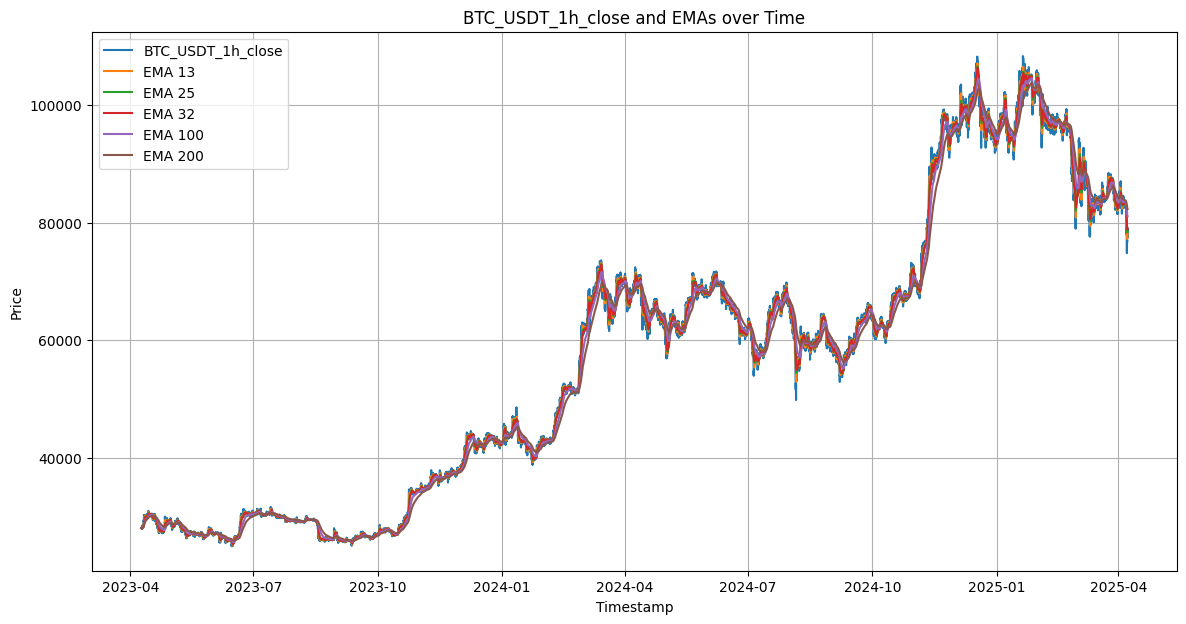

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(data_data['timestamp'], data_data['BTC_USDT_1h_close'], label='BTC_USDT_1h_close')
plt.plot(data_data['timestamp'], data_data['ema_13'], label='EMA 13')
plt.plot(data_data['timestamp'], data_data['ema_25'], label='EMA 25')
plt.plot(data_data['timestamp'], data_data['ema_32'], label='EMA 32')
plt.plot(data_data['timestamp'], data_data['ema_100'], label='EMA 100')
plt.plot(data_data['timestamp'], data_data['ema_200'], label='EMA 200')
plt.title('BTC_USDT_1h_close and EMAs over Time')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# EMA for 2 hours (candles)
data_data['vol_close_ema_3'] = data_data['vol_close'].ewm(span=3, adjust=False).mean()

# EMA for 4 hours (candles)
data_data['vol_close_ema_6'] = data_data['vol_close'].ewm(span=6, adjust=False).mean()

# EMA for 8 hours ((candles)
data_data['vol_close_ema_12'] = data_data['vol_close'].ewm(span=12, adjust=False).mean()

In [ ]:
data_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17516 entries, 0 to 17515
Columns: 109 entries, timestamp to vol_close_ema_12
dtypes: datetime64[ns](1), float64(107), int64(1)
memory usage: 14.6 MB


In [ ]:
data_data['timestamp'] = pd.to_datetime(data_data['timestamp'])

In [ ]:
columns_to_drop = ['timestamp']
data_data = data_data.drop(columns=columns_to_drop)

In [ ]:
data_data.to_csv('data_featured.csv', index=False)

In [ ]:
train_data = data_data.copy(deep=True)
train_data['hour'] = train_data.index % 24 # Add 'hour' column
train_data.reset_index(drop=True, inplace=True)

In [ ]:
train_data.head()

,BNB_USDT_1h_open,BNB_USDT_1h_high,BNB_USDT_1h_low,BNB_USDT_1h_close,BNB_USDT_1h_volume,BTC_USDT_1h_open,BTC_USDT_1h_high,BTC_USDT_1h_low,BTC_USDT_1h_close,BTC_USDT_1h_volume,...,day,ema_13,ema_25,ema_32,ema_100,ema_200,vol_close,vol_close_ema_3,vol_close_ema_6,vol_close_ema_12
0,310.5739,311.1801,310.4821,311.1801,28.717,27943.39,28073.95,27930.31,28035.04,57.560631,...,7,28035.040000,28035.040000,28035.040000,28035.040000,28035.040000,0.005124,0.005124,0.005124,0.005124
1,311.1801,311.6257,311.1489,311.6132,15.980,28035.04,28080.00,28029.69,28075.72,21.191172,...,7,28056.944615,28056.193600,28056.015625,28055.583400,28055.481700,0.001792,0.003458,0.004172,0.004611
2,311.6132,311.8623,311.2814,311.2814,37.265,28075.72,28080.84,28027.47,28033.86,38.007310,...,7,28048.037953,28048.145885,28048.164185,28048.196966,28048.202275,0.001904,0.002681,0.003524,0.004195
3,311.2814,311.4965,311.0072,311.2450,22.836,28033.86,28047.09,28019.16,28025.87,9.248042,...,7,28041.156860,28041.891557,28042.057583,28042.446667,28042.535182,0.000997,0.001839,0.002802,0.003703
4,311.2450,311.3736,311.0723,311.1659,44.535,28025.87,28038.02,28016.28,28036.28,13.992617,...,7,28039.860288,28040.582800,28040.753262,28041.163512,28041.259001,0.000775,0.001307,0.002223,0.003252


In [ ]:
class CryptoTradingEnv(gym.Env):
    def __init__(self, data, take_profit_position_range=(0.10, 0.80), stop_loss_position_range=(0.00, 0.15), max_stop_loss_position=0.30):
        super(CryptoTradingEnv, self).__init__()

        self.data = data
        self.n_steps = len(data)
        self.current_step = 0
        self.initial_balance = 10000
        self.balance = self.initial_balance
        self.position = 0
        self.position_open = 0 # Price at which the position was opened
        self.num_trades = 0  # Number of trades
        self.profit_loss = 0  # PnL Profit/Loss
        self.max_stop_loss_position = max_stop_loss_position

        self.take_profit_position_range = take_profit_position_range
        self.stop_loss_position_range = stop_loss_position_range

        # 0=Hold, 1=Open Position, 2=Close Position
        self.action_space = gym.spaces.Discrete(3)

        # Observations
        n_features = 15
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(n_features,))

        self.episode_returns = []
        self.cumulative_returns = 0
        self.winning_trades = 0
        self.losing_trades = 0
        self.hourly_returns = []

        self.overall_rewards = 0


    def step(self, action):
        self.current_step += 1
        done = False

        reward = 0
        trade_outcome = 0
        trade_within_range = False

        if action == 1:  # Open Position
            if self.position == 0:  # Only open a position if not already in a trade
                position_size = 0.05 * self.balance

                self.position_open = self.data.loc[self.current_step, 'BTC_USDT_1h_open']
                self.position = 1
                self.num_trades += 1
                print(f"Opened trade at step {self.current_step} with position size: {position_size:.2f}")
        elif action == 2:  # Close Position
            if self.position == 1:  # Only close a position if currently in a trade
                position_close = self.data.loc[self.current_step, 'BTC_USDT_1h_open']
                trade_outcome = position_close - self.position_open
                self.profit_loss += trade_outcome
                self.position = 0
                self.position_open = 0
                print(f"Closed trade at step {self.current_step}")
                print(f"------------------------------> Trade outcome: {trade_outcome}")

                self.balance += trade_outcome

                # Check for take profit and stop loss
                if trade_outcome > 0:
                    if trade_outcome >= self.take_profit_position_range[0] * self.position:
                        reward = 1  # Trade reached take profit
                        self.winning_trades += 1  # +1 winning trades count
                        if trade_outcome <= self.take_profit_position_range[1] * self.position and trade_outcome >= self.take_profit_position_range[0] * self.position:
                           # self.trade_within_range = True
                            print("Trade reached take profit")
                elif trade_outcome < 0:
                    if abs(trade_outcome) >= self.max_stop_loss_position * self.position:
                        reward = -1.7  # Trade reached the maximum stop loss
                        self.losing_trades += 1  # +1 losing trades count
                        print("Trade reached the maximum stop loss")
                    elif abs(trade_outcome) >= self.stop_loss_position_range[0] * self.position:
                        reward = -1  # Trade reached the stop loss
                        self.losing_trades += 1  # +1 losing trades count
                        print("Trade reached stop loss")
                    else:
                        # No reward (positive and negative) if the trade closed with no loss
                        reward = 0
                        print("Trade closed with no loss")

#                if trade_within_range:
#                    self.winning_trade_within_range += 1

    # reward based on profit/loss of the last trade
#        reward += trade_outcome
        if trade_outcome > 0:
            reward += 0.5
        print(f"Reward: {reward}")

        # reward for this episode
        self.episode_returns.append(reward)

        # cumulative returns
        self.cumulative_returns += reward

        # hourly returns for daily return calculation
#        self.hourly_returns.append(reward)

        self.overall_rewards += reward

        if self.current_step >= self.n_steps:
            done = True

        next_state = self.get_observation()
        return next_state, reward, done, {}


    def reset(self):
        self.current_step = 0
        self.position = 0
        self.position_open = 0
        episode_return = np.sum(self.episode_returns)
        self.episode_returns = []
        self.cumulative_returns += episode_return
        self.current_week_start = 0
        return self.get_observation()

    def render(self, mode='human'):
        if mode == 'human':
            print(f"Step: {self.current_step}")
            print(f"Open Position: {self.position}")
            print(f"Trades: {self.num_trades} | Profit/Loss: {self.profit_loss:.2f}")
            print(f"Balance: {self.balance:.2f}")
            print(f"Winning Trades: {self.winning_trades} | Losing Trades: {self.losing_trades}")
            print(f"Overall Rewards: {self.overall_rewards:.2f}")
            print(self.data.loc[self.current_step])

    def close(self):
        pass

    def get_observation(self):
        obs = self.data.loc[self.current_step, [
            'BTC_USDT_1h_open', 'BTC_USDT_1h_high', 'BTC_USDT_1h_low', 'BTC_USDT_1h_close', 'BTC_USDT_1h_volume', 'hour', 'day',
            'ema_13', 'ema_25', 'ema_32', 'ema_100', 'ema_200', 'vol_close_ema_3', 'vol_close_ema_6', 'vol_close_ema_12'
        ]].values.astype(np.float32)
        return obs / obs.max()

In [ ]:
num_episodes = 5000
print_interval = 100

env = CryptoTradingEnv(train_data)

obs = env.reset()

agent = PPO("MlpPolicy", DummyVecEnv([lambda: env]), verbose=1, tensorboard_log="./ppo_logs/")

max_steps = 50000 # I was getting error for out of index so i limited the max step

for episode in range(num_episodes):
    obs = np.array(obs, dtype=np.float32)
    action, _ = agent.predict(obs, deterministic=False)

    remaining_steps = min(max_steps - env.current_step, env.n_steps)

    if remaining_steps > 0:
        obs, reward, done, _ = env.step(action)
        env.render()

#    if done:
#        obs = env.reset()

    if (episode + 1) % print_interval == 0:
        print(f"Episode {episode + 1}: Final Rewards: {env.cumulative_returns:.2f} | Total Trades: {env.num_trades}")


Streaming output truncated to the last 5000 lines.
BNB_USDT_1h_low       219.384800
BNB_USDT_1h_close     220.525600
BNB_USDT_1h_volume    183.325270
                         ...    
vol_close               0.016529
vol_close_ema_3         0.014237
vol_close_ema_6         0.012062
vol_close_ema_12        0.010518
hour                   17.000000
Name: 4745, Length: 109, dtype: float64
Reward: 0
Step: 4746
Open Position: 1
Trades: 806 | Profit/Loss: -5118.25
Balance: 4881.75
Winning Trades: 388 | Losing Trades: 417
Overall Rewards: -126.90
BNB_USDT_1h_open      220.525600
BNB_USDT_1h_high      221.256300
BNB_USDT_1h_low       219.564800
BNB_USDT_1h_close     221.256300
BNB_USDT_1h_volume    210.706790
                         ...    
vol_close               0.016494
vol_close_ema_3         0.015366
vol_close_ema_6         0.013329
vol_close_ema_12        0.011438
hour                   18.000000
Name: 4746, Length: 109, dtype: float64
Reward: 0
Step: 4747
Open Position: 1
Trades: 806 | 

In [ ]:
agent.save('v1_ppodrl')

In [ ]:
val_data = train_data

In [ ]:
val_data = val_data.reset_index(drop=True)

In [ ]:
val_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17516 entries, 0 to 17515
Columns: 109 entries, BNB_USDT_1h_open to hour
dtypes: float64(107), int64(2)
memory usage: 14.6 MB


In [ ]:
val_data.head()

,BNB_USDT_1h_open,BNB_USDT_1h_high,BNB_USDT_1h_low,BNB_USDT_1h_close,BNB_USDT_1h_volume,BTC_USDT_1h_open,BTC_USDT_1h_high,BTC_USDT_1h_low,BTC_USDT_1h_close,BTC_USDT_1h_volume,...,ema_13,ema_25,ema_32,ema_100,ema_200,vol_close,vol_close_ema_3,vol_close_ema_6,vol_close_ema_12,hour
0,310.5739,311.1801,310.4821,311.1801,28.717,27943.39,28073.95,27930.31,28035.04,57.560631,...,28035.040000,28035.040000,28035.040000,28035.040000,28035.040000,0.005124,0.005124,0.005124,0.005124,0
1,311.1801,311.6257,311.1489,311.6132,15.980,28035.04,28080.00,28029.69,28075.72,21.191172,...,28056.944615,28056.193600,28056.015625,28055.583400,28055.481700,0.001792,0.003458,0.004172,0.004611,1
2,311.6132,311.8623,311.2814,311.2814,37.265,28075.72,28080.84,28027.47,28033.86,38.007310,...,28048.037953,28048.145885,28048.164185,28048.196966,28048.202275,0.001904,0.002681,0.003524,0.004195,2
3,311.2814,311.4965,311.0072,311.2450,22.836,28033.86,28047.09,28019.16,28025.87,9.248042,...,28041.156860,28041.891557,28042.057583,28042.446667,28042.535182,0.000997,0.001839,0.002802,0.003703,3
4,311.2450,311.3736,311.0723,311.1659,44.535,28025.87,28038.02,28016.28,28036.28,13.992617,...,28039.860288,28040.582800,28040.753262,28041.163512,28041.259001,0.000775,0.001307,0.002223,0.003252,4


In [ ]:
pre_trained_agent = PPO.load('v1_ppodrl')

In [ ]:
env_test = CryptoTradingEnv(val_data)
obs = env_test.reset()

num_episodes = 1000

for episode in range(num_episodes):
  obs = np.array(obs, dtype=np.float32)
  action, _ = agent.predict(obs, deterministic=True)

  remaining_steps = min(max_steps - env_test.current_step, env_test.n_steps)

if remaining_steps > 0:
  obs, reward, done, _ = env_test.step(action)
  env_test.render()

if (episode + 1) % print_interval == 0:
  print(f"Episode {episode + 1}: Final Rewards: {env_test.cumulative_returns:.2f} | Total Trades: {env_test.num_trades}")

Reward: 0
Step: 1
Open Position: 0
Trades: 0 | Profit/Loss: 0.00
Balance: 10000.00
Winning Trades: 0 | Losing Trades: 0
Overall Rewards: 0.00
BNB_USDT_1h_open      311.180100
BNB_USDT_1h_high      311.625700
BNB_USDT_1h_low       311.148900
BNB_USDT_1h_close     311.613200
BNB_USDT_1h_volume     15.980000
                         ...    
vol_close               0.001792
vol_close_ema_3         0.003458
vol_close_ema_6         0.004172
vol_close_ema_12        0.004611
hour                    1.000000
Name: 1, Length: 109, dtype: float64
Episode 1000: Final Rewards: 0.00 | Total Trades: 0


In [ ]:
import numpy as np
A = np.array([])